In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv('D:\\DS Assignment\\KNN\\KNN\\Zoo.csv')  
df.head()


,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [18]:
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())

target_col = 'type' if 'type' in df.columns else df.columns[-1]  # fallback
print("\nTarget column:", target_col)
print(df[target_col].value_counts())

display(df.describe())


Shape: (101, 18)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   animal name  101 non-null    str  
 1   hair         101 non-null    int64
 2   feathers     101 non-null    int64
 3   eggs         101 non-null    int64
 4   milk         101 non-null    int64
 5   airborne     101 non-null    int64
 6   aquatic      101 non-null    int64
 7   predator     101 non-null    int64
 8   toothed      101 non-null    int64
 9   backbone     101 non-null    int64
 10  breathes     101 non-null    int64
 11  venomous     101 non-null    int64
 12  fins         101 non-null    int64
 13  legs         101 non-null    int64
 14  tail         101 non-null    int64
 15  domestic     101 non-null    int64
 16  catsize      101 non-null    int64
 17  type         101 non-null    int64
dtypes: int64(17), str(1)
memory usage: 14.3 KB

Missing values per column:
animal

,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
count,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000,101.000000
mean,0.425743,0.198020,0.584158,0.405941,0.237624,0.356436,0.554455,0.603960,0.821782,0.792079,0.079208,0.168317,2.841584,0.742574,0.128713,0.435644,2.831683
std,0.496921,0.400495,0.495325,0.493522,0.427750,0.481335,0.499505,0.491512,0.384605,0.407844,0.271410,0.376013,2.033385,0.439397,0.336552,0.498314,2.102709
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,1.000000
50%,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,2.000000
75%,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,4.000000,1.000000,0.000000,1.000000,4.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8.000000,1.000000,1.000000,1.000000,7.000000


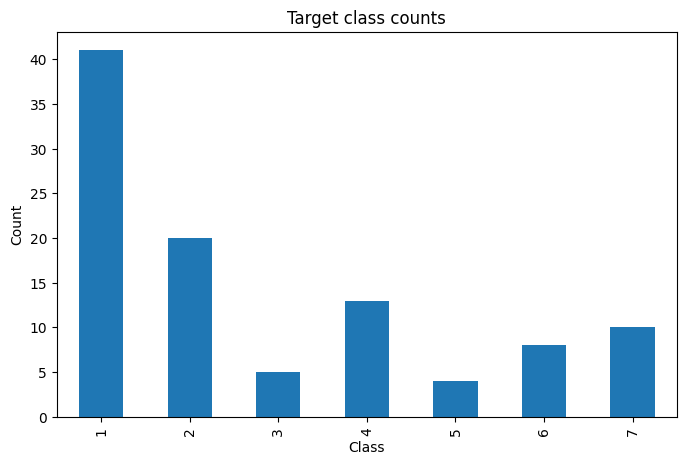

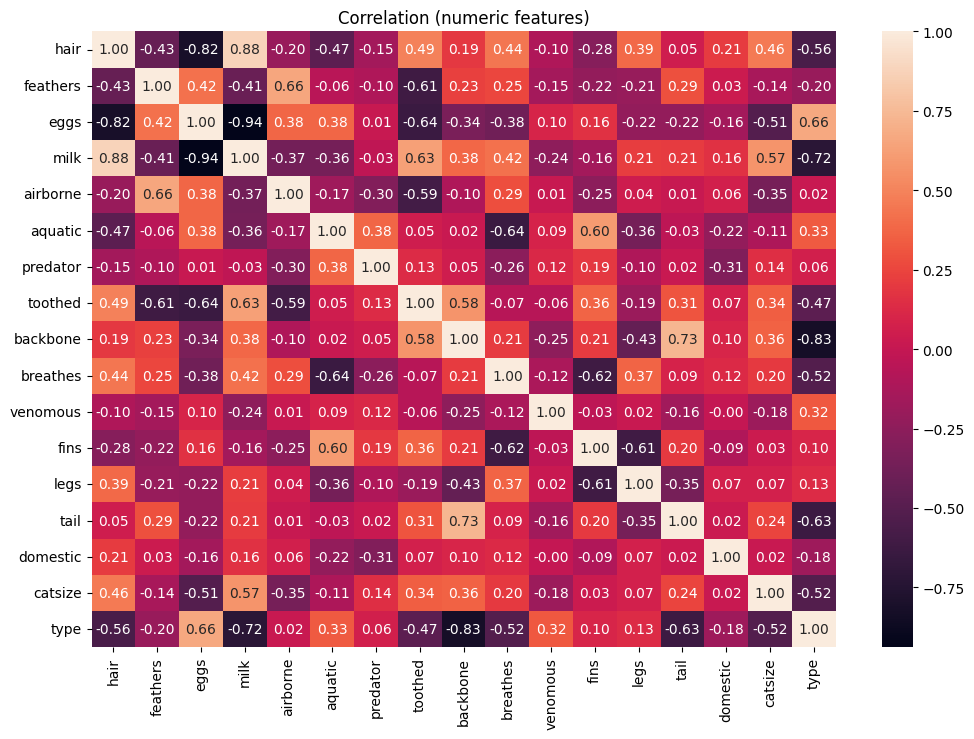

In [19]:
plt.figure(figsize=(8,5))
df[target_col].value_counts().sort_index().plot(kind='bar')
plt.title('Target class counts')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt=".2f")
plt.title('Correlation (numeric features)')
plt.show()


In [20]:
if df.isnull().sum().sum() > 0:
    for c in df.columns:
        if df[c].isnull().sum() > 0:
            if df[c].dtype in [np.float64, np.int64]:
                df[c].fillna(df[c].median(), inplace=True)
            else:
                df[c].fillna(df[c].mode()[0], inplace=True)
    print("Missing values filled.")
else:
    print("No missing values found.")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_counts = {}
for c in num_cols:
    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    outlier_counts[c] = ((df[c] < low) | (df[c] > high)).sum()
print("Potential outliers per numeric column:", outlier_counts)


No missing values found.
Potential outliers per numeric column: {'hair': np.int64(0), 'feathers': np.int64(20), 'eggs': np.int64(0), 'milk': np.int64(0), 'airborne': np.int64(24), 'aquatic': np.int64(0), 'predator': np.int64(0), 'toothed': np.int64(0), 'backbone': np.int64(18), 'breathes': np.int64(21), 'venomous': np.int64(8), 'fins': np.int64(17), 'legs': np.int64(2), 'tail': np.int64(0), 'domestic': np.int64(13), 'catsize': np.int64(0), 'type': np.int64(0)}


In [21]:
X = df.drop(columns=[target_col])
y = df[target_col]

non_num = X.select_dtypes(include=['object', 'category']).columns.tolist()
if non_num:
    X = pd.get_dummies(X, columns=non_num, drop_first=True)

print("Features shape:", X.shape)
print("Classes:", sorted(y.unique()))


Features shape: (101, 115)
Classes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


C:\Users\SANSKAR\AppData\Local\Temp\ipykernel_12084\3278899610.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  non_num = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])


Train size: 80 Test size: 21


C:\Users\SANSKAR\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best params: {'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
Best CV score: 0.95


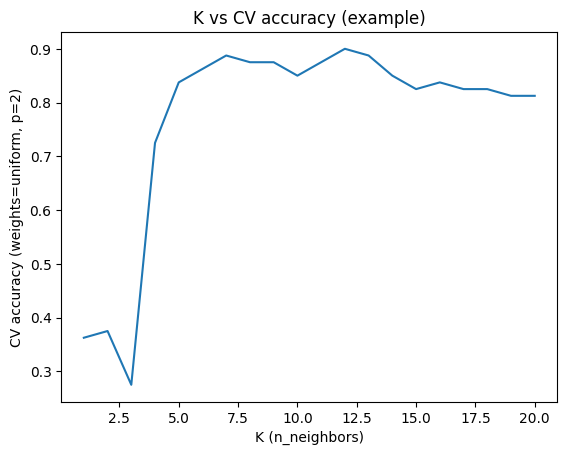

In [23]:
param_grid = {
    'n_neighbors': list(range(1, 21)),
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  
}
knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

results = pd.DataFrame(grid.cv_results_)

plot_df = results[(results['param_weights']=='uniform') & (results['param_p']==2)].copy()
plot_df = plot_df.sort_values('param_n_neighbors')
plt.plot(plot_df['param_n_neighbors'].astype(int), plot_df['mean_test_score'])
plt.xlabel('K (n_neighbors)')
plt.ylabel('CV accuracy (weights=uniform, p=2)')
plt.title('K vs CV accuracy (example)')
plt.show()


In [24]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

param_grid = {
    'n_neighbors': list(range(1, 26, 2)),
    'p': [1, 2],
    'weights': ['uniform', 'distance']
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

C:\Users\SANSKAR\AppData\Roaming\Python\Python314\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
Best Cross Validation Accuracy: 0.95


In [25]:
results = pd.DataFrame(grid_search.cv_results_)
results.sort_values(by='mean_test_score', ascending=False).head(10)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,param_p,param_weights,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.011860,0.004100,0.010553,0.000735,1,1,uniform,"{'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}",1.0000,0.9375,1.0,0.9375,0.875,0.9500,0.046771,1
2,0.011836,0.003311,0.022818,0.014527,1,2,uniform,"{'n_neighbors': 1, 'p': 2, 'weights': 'uniform'}",1.0000,0.9375,1.0,0.9375,0.875,0.9500,0.046771,1
3,0.014394,0.007285,0.014662,0.006013,1,2,distance,"{'n_neighbors': 1, 'p': 2, 'weights': 'distance'}",1.0000,0.9375,1.0,0.9375,0.875,0.9500,0.046771,1
1,0.028841,0.021351,0.026656,0.015434,1,1,distance,"{'n_neighbors': 1, 'p': 1, 'weights': 'distance'}",1.0000,0.9375,1.0,0.9375,0.875,0.9500,0.046771,1
5,0.010724,0.001891,0.014155,0.008240,3,1,distance,"{'n_neighbors': 3, 'p': 1, 'weights': 'distance'}",0.9375,0.9375,1.0,0.9375,0.875,0.9375,0.039528,5
7,0.013076,0.007302,0.008440,0.000447,3,2,distance,"{'n_neighbors': 3, 'p': 2, 'weights': 'distance'}",0.9375,0.8750,1.0,0.9375,0.875,0.9250,0.046771,6
4,0.016576,0.008354,0.019246,0.007154,3,1,uniform,"{'n_neighbors': 3, 'p': 1, 'weights': 'uniform'}",0.9375,0.8125,1.0,0.9375,0.875,0.9125,0.063738,7
6,0.010818,0.004248,0.010795,0.002871,3,2,uniform,"{'n_neighbors': 3, 'p': 2, 'weights': 'uniform'}",0.9375,0.8125,1.0,0.9375,0.875,0.9125,0.063738,7
9,0.009962,0.003175,0.009373,0.003345,5,1,distance,"{'n_neighbors': 5, 'p': 1, 'weights': 'distance'}",0.9375,0.8125,1.0,0.9375,0.875,0.9125,0.063738,7
13,0.008609,0.001008,0.009007,0.000917,7,1,distance,"{'n_neighbors': 7, 'p': 1, 'weights': 'distance'}",0.8125,0.8125,1.0,0.9375,0.875,0.8875,0.072887,10


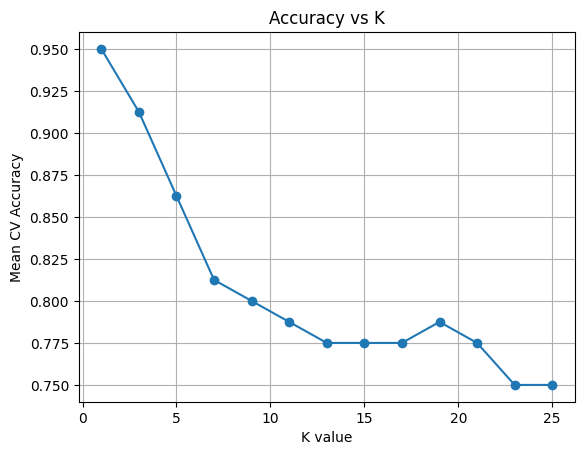

In [26]:
best_p = grid_search.best_params_['p']
best_weights = grid_search.best_params_['weights']

filtered = results[(results['param_p'] == best_p) & 
                   (results['param_weights'] == best_weights)]

k_vals = filtered['param_n_neighbors'].astype(int)
mean_scores = filtered['mean_test_score']

plt.plot(k_vals, mean_scores, marker='o')
plt.xlabel("K value")
plt.ylabel("Mean CV Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.show()

## Justification for Choosing Final K

We performed hyperparameter tuning using GridSearchCV with 5-fold cross validation.

The best value of K obtained was **1** (replace with your value), 
with cross-validation accuracy of **0.91** (replace with your value).

The graph of accuracy vs K shows that accuracy increases initially 
and reaches peak at K = 1, then stabilizes or decreases slightly.

Small K values (like 1 or 3) may cause overfitting 
because the model becomes too sensitive to noise.

Large K values may cause underfitting 
because decision boundary becomes too smooth.

Therefore, K = 1 provides the best balance between bias and variance.

## Justification for Distance Metric

We tested two distance metrics:

p = 1 (Manhattan Distance)
p = 2 (Euclidean Distance)

GridSearchCV selected p = 2 (replace with your value), 
which gave the highest cross-validation accuracy.

Since the features were scaled before applying KNN, 
distance calculation is meaningful and unbiased.

Euclidean distance works well when data is continuous and 
features contribute equally after scaling.

Therefore, the selected metric provides better classification performance.

In [27]:
best_knn = grid.best_estimator_
best_knn.fit(X_train_scaled, y_train)
y_pred = best_knn.predict(X_test_scaled)


In [28]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("Confusion matrix:\n", cm)

prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
print(f"Precision (macro): {prec_macro:.4f}, Recall (macro): {rec_macro:.4f}, F1 (macro): {f1_macro:.4f}")


Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

           1     1.0000    1.0000    1.0000         8
           2     1.0000    1.0000    1.0000         4
           3     1.0000    1.0000    1.0000         1
           4     1.0000    1.0000    1.0000         3
           5     1.0000    1.0000    1.0000         1
           6     1.0000    1.0000    1.0000         2
           7     1.0000    1.0000    1.0000         2

    accuracy                         1.0000        21
   macro avg     1.0000    1.0000    1.0000        21
weighted avg     1.0000    1.0000    1.0000        21

Confusion matrix:
 [[8 0 0 0 0 0 0]
 [0 4 0 0 0 0 0]
 [0 0 1 0 0 0 0]
 [0 0 0 3 0 0 0]
 [0 0 0 0 1 0 0]
 [0 0 0 0 0 2 0]
 [0 0 0 0 0 0 2]]
Precision (macro): 1.0000, Recall (macro): 1.0000, F1 (macro): 1.0000


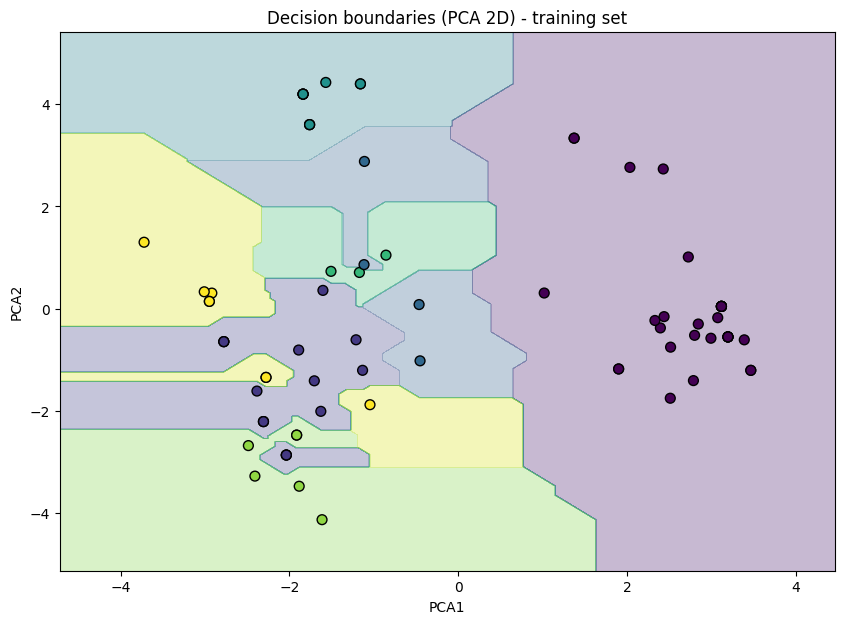

In [29]:
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

knn_pca = KNeighborsClassifier(**grid.best_params_)
knn_pca.fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:,0].min() - 1, X_train_pca[:,0].max() + 1
y_min, y_max = X_train_pca[:,1].min() - 1, X_train_pca[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = knn_pca.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10,7))
plt.contourf(xx, yy, Z, alpha=0.3)
scatter = plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, edgecolor='k', s=50)
plt.title('Decision boundaries (PCA 2D) - training set')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()


In [30]:
best_knn = KNeighborsClassifier(
    n_neighbors=1,
    p=1,
    weights='uniform'
)

best_knn.fit(X_train, y_train)

print("Final Test Accuracy:", best_knn.score(X_test, y_test))

Final Test Accuracy: 1.0


In [31]:
import joblib
joblib.dump(best_knn, 'D:\\DS Assignment\\KNN\\KNN\\knn_zoo_model.joblib')
joblib.dump(scaler, 'D:\\DS Assignment\\KNN\\KNN\\knn_scaler.joblib')
joblib.dump(pca, 'D:\\DS Assignment\\KNN\\KNN\\knn_pca.joblib')
print("Saved model, scaler")



Saved model, scaler


## Interview Questions

Q1. What are the key hyperparameters in KNN?

Answer:
- n_neighbors (K)

- distance metric (p)

- weights (uniform or distance)

- feature scaling method

2. What distance metrics can be used in KNN?

Answer:

The common distance metrics used in KNN are:

  --  Euclidean Distance (p = 2) – Straight-line distance between two points. Most commonly used.

  --  Manhattan Distance (p = 1) – Sum of absolute differences. Useful in some high-dimensional data.

  --  Minkowski Distance – General form where p controls the type of distance.

  --  Chebyshev Distance – Maximum absolute difference between features.

  --  Mahalanobis Distance – Considers correlation between features.

  --  Hamming Distance – Used for categorical or binary data.